# Defining the upwelling region 

In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
def coastal_band_mask(ds, var='u10', target_width_km=111):
    """
    Create a coastal band mask with uniform cross-shore width in km.
    """
    da = ds[var]
    if 'time' in da.dims:
        da = da.mean(dim='time')

    valid2d = np.isfinite(da).values.astype(bool)
    lat_vals = ds['lat'].values
    lon_vals = ds['lon'].values
    dlon = np.abs(lon_vals[1] - lon_vals[0])  # grid spacing in degrees

    # Find coastline (easternmost valid cell per row)
    band = np.zeros_like(valid2d, dtype=bool)

    for j in range(valid2d.shape[0]):
        row = valid2d[j, :]
        ocean_cols = np.where(row)[0]
        if len(ocean_cols) == 0:
            continue

        # Coast = easternmost valid cell
        i_coast = ocean_cols[-1]

        # How many cells = target_width_km at this latitude?
        A = 6371.0  # km
        dx_km = A * np.cos(np.deg2rad(lat_vals[j])) * np.deg2rad(dlon)
        n_cells = int(np.round(target_width_km / dx_km))

        # Fill n_cells westward from coast
        i_start = max(i_coast - n_cells, 0)
        band[j, i_start:i_coast + 1] = True

    # Only keep cells that are actually ocean
    band = band & valid2d

    da_mask = xr.DataArray(band, dims=('lat', 'lon'),
                           coords={'lat': ds['lat'], 'lon': ds['lon']})
    return da_mask

In [3]:
def get_boundary_lons(ds, var='WMLD', target_width_km=111, lon_slice=None, lat_slice=None):
    """
    Applies coastal masking, spatial slicing, and calculates boundary longitudes.
    
    Parameters:
    ds: xarray.Dataset or DataArray
    var: str, variable name to analyze
    target_width_km: int, width for the coastal_band_mask
    lon_slice: slice, e.g., slice(-85, None)
    lat_slice: slice, e.g., slice(-17, -4)
    """
    # 1. Apply the coastal band mask (assuming this function is defined in your environment)
    mask = coastal_band_mask(ds, var=var, target_width_km=target_width_km)
    
    # 2. Select region and apply mask
    # We slice first, then mask to keep the operations light
    ds_subset = ds.sel(lon=lon_slice, lat=lat_slice)
    data = ds_subset[var].where(mask).isel(time=0)
    
    # 3. Vectorized boundary finding
    valid = data.notnull()
    
    # Find edges using shift
    valid_e = valid.shift(lon=-1).fillna(False)
    valid_w = valid.shift(lon=1).fillna(False)
    
    coast_mask = valid & (~valid_e)      # Easternmost valid cell
    offshore_mask = valid & (~valid_w)   # Westernmost valid cell
    
    # Extract longitudes
    coast_lons = data.lon.where(coast_mask).min(dim='lon')
    offshore_lons = data.lon.where(offshore_mask).min(dim='lon')
    
    return coast_lons, offshore_lons

In [4]:
wmld = xr.open_dataset('W_mld_Croco.nc').compute()
wmld = wmld.sel(lon=slice(-85,None),lat=slice(-17,-4))

mask = coastal_band_mask(wmld, var='WMLD', target_width_km=500) # ~111 km cross-shore
WMLD = wmld.where(mask).sel(lon=slice(-85, None), lat=slice(-17,-4))

In [5]:
# ============================================================
# 3. Find coastal and offshore boundary longitudes per latitude
# ============================================================
coast_lons, offshore_lons = get_boundary_lons(
    wmld, 
    var='WMLD', 
    target_width_km=500,
    lon_slice=slice(-85, None), 
    lat_slice=slice(-17, -4)
)

### 111 km
coast_lons, offshore_lons_111 = get_boundary_lons(
    wmld, 
    var='WMLD', 
    target_width_km=111,
    lon_slice=slice(-85, None), 
    lat_slice=slice(-17, -4)
)

### 150 km
coast_lons, offshore_lons_150 = get_boundary_lons(
    wmld, 
    var='WMLD', 
    target_width_km=150,
    lon_slice=slice(-85, None), 
    lat_slice=slice(-17, -4)
)

### 200 km
coast_lons, offshore_lons_200 = get_boundary_lons(
    wmld, 
    var='WMLD', 
    target_width_km=200,
    lon_slice=slice(-85, None), 
    lat_slice=slice(-17, -4)
)

### 250 km
coast_lons, offshore_lons_250 = get_boundary_lons(
    wmld, 
    var='WMLD', 
    target_width_km=250,
    lon_slice=slice(-85, None), 
    lat_slice=slice(-17, -4)
)

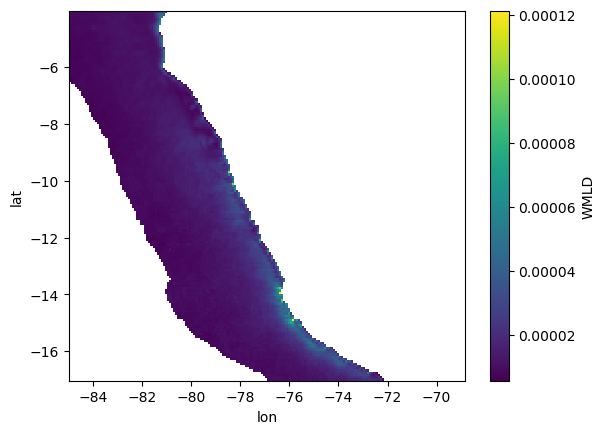

In [6]:
WMLD.WMLD.std('time').plot()

Text(0.5, 1.0, 'coast / offshore boundary detection')

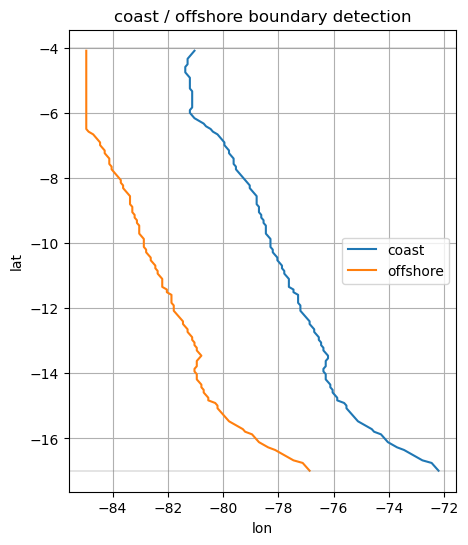

In [7]:
fig, ax = plt.subplots(figsize=(5, 6))
ax.plot(coast_lons, wmld.lat, label='coast')
ax.plot(offshore_lons, wmld.lat, label='offshore')
ax.set_xlabel('lon'); ax.set_ylabel('lat')
ax.axhline(-4,  color='grey', lw=0.3)
ax.axhline(-17, color='grey', lw=0.3)
ax.legend(); ax.grid(True)
ax.set_title('coast / offshore boundary detection')

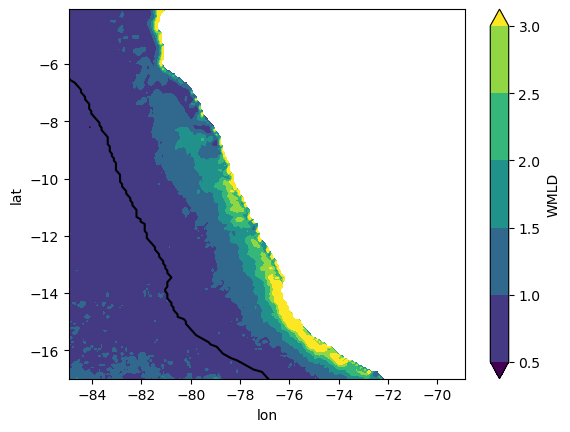

In [8]:
(wmld*60*60*24).std('time').WMLD.plot.contourf(robust=True)
plt.plot(offshore_lons, wmld.lat, label='offshore',color='black')

In [9]:
# 1. Ensure your data is 'chunked' to allow Dask to work
# Adjust chunks based on your HPC memory (e.g., {'time': 10, 'lat': 100})
W = (WMLD  * 60 * 60 * 24).WMLD.chunk({'time': 20, 'lat': 200})

# 2. Vectorized Quantile Calculation
# This calculates the 90th percentile across the 'lon' dimension for ALL time and lat at once
thresholds = W.quantile(0.90, dim='lon')

# 3. Vectorized Masking
# Keep only values that are >= the calculated threshold
# .where sets everything else to NaN
masked_W = W.where(W >= thresholds)

# 4. Extract the max longitude
# We use the longitude coordinates, keeping only where the condition is met, 
# and taking the max along the 'lon' dimension.
loni_da = masked_W.lon.where(masked_W.notnull()).min(dim='lon')

# 5. Compute (This is where Dask triggers the parallel execution)
# If your data is very large, this may take a moment.
loni_da = loni_da.compute()

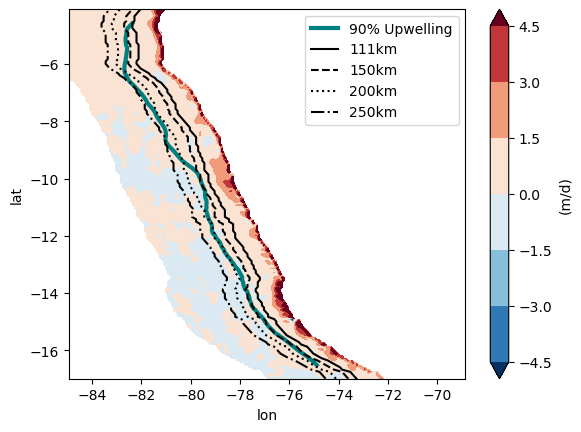

In [15]:
loni_da.mean('time').rolling(lat=13,center=True).mean().plot(y='lat',color='teal',label='90% Upwelling', linewidth=3)
(WMLD*60*60*24).mean('time').WMLD.rename('(m/d)').plot.contourf(robust=True)

# plt.plot(offshore_lons, wmld.lat, label='offshore',color='black')
plt.plot(offshore_lons_111, wmld.lat, label='111km',color='black')
plt.plot(offshore_lons_150, wmld.lat, label='150km',linestyle='--',color='black')
plt.plot(offshore_lons_200, wmld.lat, label='200km',linestyle=':',color='black')
plt.plot(offshore_lons_250, wmld.lat, label='250km',linestyle='-.',color='black')

plt.legend()

Text(0.5, 1.0, 'Smoothed 90% percentile')

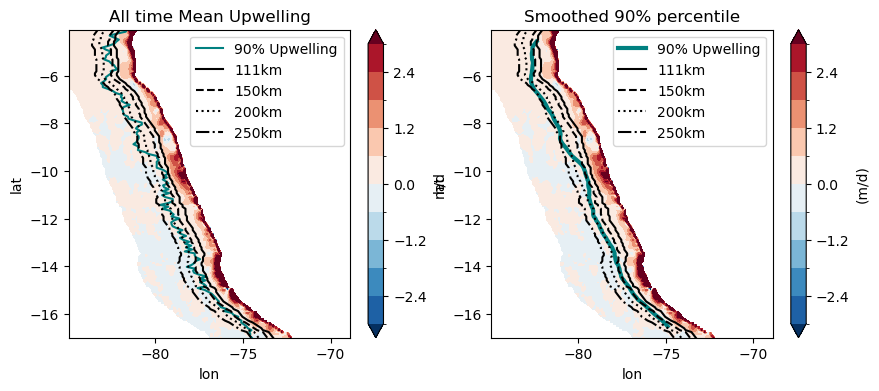

In [23]:
fig, ax = plt.subplots(1,2,figsize=(10,4))

loni_da.mean('time').plot(y='lat',color='teal',label='90% Upwelling',ax=ax[0])
(WMLD*60*60*24).mean('time').WMLD.rename('m/d').plot.contourf(
    robust=True,vmin=-3,vmax=3,levels=11,cmap='RdBu_r', ax=ax[0])

# plt.plot(offshore_lons, wmld.lat, label='offshore',color='black')
ax[0].plot(offshore_lons_111, wmld.lat, label='111km',color='black')
ax[0].plot(offshore_lons_150, wmld.lat, label='150km',linestyle='--',color='black')
ax[0].plot(offshore_lons_200, wmld.lat, label='200km',linestyle=':',color='black')
ax[0].plot(offshore_lons_250, wmld.lat, label='250km',linestyle='-.',color='black')

## smoothed 90%
loni_da.mean('time').rolling(lat=13,center=True).mean().plot(y='lat',color='teal',label='90% Upwelling', linewidth=3,ax=ax[1])
(WMLD*60*60*24).mean('time').WMLD.rename('(m/d)').plot.contourf(robust=True,vmin=-3,vmax=3,levels=11,cmap='RdBu_r', ax=ax[1])
# plt.plot(offshore_lons, wmld.lat, label='offshore',color='black')
ax[1].plot(offshore_lons_111, wmld.lat, label='111km',color='black')
ax[1].plot(offshore_lons_150, wmld.lat, label='150km',linestyle='--',color='black')
ax[1].plot(offshore_lons_200, wmld.lat, label='200km',linestyle=':',color='black')
ax[1].plot(offshore_lons_250, wmld.lat, label='250km',linestyle='-.',color='black')

ax[0].legend()

ax[1].legend()
ax[0].set_title('All time Mean Upwelling')
ax[1].set_title('Smoothed 90% percentile')

Text(0.5, 1.0, 'All time $W_{MLD}$')

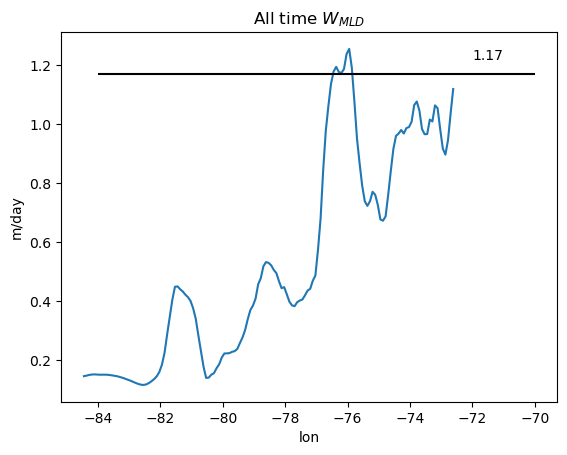

In [42]:
ww = (WMLD*60*60*24).mean('time').WMLD.mean('lat')
ww.rename('m/day').rolling(lon=12,center=True).mean().plot()
thr = ww.rolling(lon=12,center=True).mean().quantile(0.95)
plt.hlines(thr,-84,-70,color='black')
plt.text(-72,thr+0.05,str(np.round(thr.data,2)))
plt.title('All time $W_{MLD}$')

<xarray.DataArray 'WMLD' ()> Size: 8B
array(1.57557065)
Coordinates:
    quantile  float64 8B 0.95